# Transfer Learning & Fine-Tuning MobileNet

**Goal:** take a MobileNetV2 pretrained on ImageNet and adapt it to a 2-class problem (cat vs dog).

**Pipeline:**
1. Load Oxford-IIIT Pet as a binary cat/dog dataset, with augmentation.
2. Swap MobileNet's 1000-class head for a fresh 2-class head.
3. **Freeze** the backbone, train only the head (feature-extraction mode). Measure F1.
4. **Progressively unfreeze** the last blocks, fine-tune with a low LR. Measure F1 again.
5. Checkpoint the best model (weights + optimizer state).

**Why this matters:** this is how almost all production CV is actually done — nobody trains from scratch.

## Cell 1 — Setup: imports, device, hyperparameters

Standard preamble. Two things specific to today:

- **Two learning rates.** `HEAD_LR` (large, `1e-3`) for the fresh random head — it has far to travel. `FINETUNE_LR` (small, `1e-4`) for when we later unfreeze the backbone — those weights are already near-optimal and a big LR would cause *catastrophic forgetting*.
- **`SUBSET_PER_CLASS`.** We're on CPU, so we cap each class to keep epochs fast. Transfer learning works precisely *because* it needs little data — a few hundred images per class is plenty when the backbone is pretrained.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# --- Hyperparameters ---
BATCH_SIZE      = 32
HEAD_LR         = 1e-3    # fresh head: far from optimal, big steps
FINETUNE_LR     = 1e-4    # unfrozen backbone: near-optimal, tiny steps (avoid catastrophic forgetting)
HEAD_EPOCHS     = 4       # Phase 1: train head only
FINETUNE_EPOCHS = 3       # Phase 2: unfreeze last blocks + fine-tune
SUBSET_PER_CLASS = 500    # cap images/class so CPU epochs stay fast
SEED            = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ImageNet normalization stats — REQUIRED for any ImageNet-pretrained model.
# (Same values you used for ResNet in the ResNet project.)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"torch {torch.__version__}, torchvision {torchvision.__version__}")
print(f"HEAD_LR={HEAD_LR}, FINETUNE_LR={FINETUNE_LR}  (ratio {HEAD_LR/FINETUNE_LR:.0f}x)")


device: cpu
torch 2.8.0+cpu, torchvision 0.23.0+cpu
HEAD_LR=0.001, FINETUNE_LR=0.0001  (ratio 10x)


## Cell 2 — Data: two transform pipelines + balanced train/val/test split

**Two pipelines, because train and val/test have different jobs:**

- **`train_transform`** — augmented. `RandomResizedCrop` (random zoom/aspect), `RandomHorizontalFlip` (a flipped cat is still a cat), `ColorJitter` (lighting variation). Each epoch the model sees a slightly different version of every image → harder to memorize → better generalization.
- **`eval_transform`** — deterministic. `Resize(256) → CenterCrop(224)`, no randomness. Val/test must measure the *real* distribution; augmenting them would make the metric noisy and meaningless.

Both end with `Normalize(IMAGENET_MEAN, IMAGENET_STD)` — non-negotiable for a pretrained backbone (from the ResNet project: wrong normalization = silent garbage).

**The two-dataset trick:** a transform is bound to the dataset object, but train and val come from the *same* `trainval` split. So we build **two** dataset objects over that split (one augmented, one clean) and give them **disjoint indices**. `test` is Oxford Pet's separate built-in split.

We cap images per class (CPU budget) and keep the split **balanced** so accuracy and F1 are directly comparable today. Labels: **0 = Cat, 1 = Dog**.

In [2]:
DATA_ROOT     = "data"   # dataset downloads to finetune/data/oxford-iiit-pet
VAL_FRACTION  = 0.2      # 20% of the capped trainval set becomes validation
TEST_PER_CLASS = 300     # cap the test set too (CPU inference budget)

# --- Two transform pipelines ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# --- Two dataset objects over the SAME trainval split (different transforms) ---
# download=True only does work on first run; afterwards it just verifies.
trainval_aug  = datasets.OxfordIIITPet(DATA_ROOT, split="trainval", target_types="binary-category",
                                       transform=train_transform, download=True)
trainval_eval = datasets.OxfordIIITPet(DATA_ROOT, split="trainval", target_types="binary-category",
                                       transform=eval_transform, download=True)
test_full     = datasets.OxfordIIITPet(DATA_ROOT, split="test", target_types="binary-category",
                                       transform=eval_transform, download=True)

print("classes:", trainval_aug.bin_classes, "->", trainval_aug.bin_class_to_idx)

# --- Build a BALANCED, capped subset of trainval, then split into train/val indices ---
bin_labels = np.array(trainval_aug._bin_labels)   # available without loading images
print("full trainval size:", len(bin_labels), "| label counts:", np.bincount(bin_labels))

rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []
for cls in [0, 1]:                                  # 0=Cat, 1=Dog
    cls_idx = np.where(bin_labels == cls)[0]
    rng.shuffle(cls_idx)
    cls_idx = cls_idx[:SUBSET_PER_CLASS]            # cap per class -> balanced
    n_val = int(len(cls_idx) * VAL_FRACTION)
    val_idx.extend(cls_idx[:n_val].tolist())
    train_idx.extend(cls_idx[n_val:].tolist())

# train indices read from the AUGMENTED dataset; val indices from the CLEAN one
train_ds = Subset(trainval_aug,  train_idx)
val_ds   = Subset(trainval_eval, val_idx)

# --- Balanced, capped test set from the separate test split ---
test_labels = np.array(test_full._bin_labels)
test_idx = []
for cls in [0, 1]:
    cls_idx = np.where(test_labels == cls)[0]
    rng.shuffle(cls_idx)
    test_idx.extend(cls_idx[:TEST_PER_CLASS].tolist())
test_ds = Subset(test_full, test_idx)

print(f"\ntrain: {len(train_ds)}  | val: {len(val_ds)}  | test: {len(test_ds)}")
print("train label counts:", np.bincount(bin_labels[train_idx]))
print("val   label counts:", np.bincount(bin_labels[val_idx]))
print("test  label counts:", np.bincount(test_labels[test_idx]))

# --- DataLoaders ---
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# --- Sanity: one batch, print shapes ---
imgs, labels = next(iter(train_loader))
print("\none train batch -> images:", imgs.shape, "| labels:", labels.shape)
print("label dtype:", labels.dtype, "| unique:", labels.unique().tolist())


100%|██████████| 792M/792M [02:00<00:00, 6.59MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.1MB/s]


classes: ['Cat', 'Dog'] -> {'Cat': 0, 'Dog': 1}
full trainval size: 3680 | label counts: [1188 2492]

train: 800  | val: 200  | test: 600
train label counts: [400 400]
val   label counts: [100 100]
test  label counts: [300 300]

one train batch -> images: torch.Size([32, 3, 224, 224]) | labels: torch.Size([32])
label dtype: torch.int64 | unique: [0, 1]


## Cell 3 — Load MobileNetV2 and swap the head

MobileNetV2 splits into two attributes:
- **`model.features`** — the conv backbone (depthwise-separable blocks) that turns a `(3, 224, 224)` image into a `(1280, 7, 7)` feature map, then pooling gives a **1280-dim feature vector**.
- **`model.classifier`** — the head: `Sequential(Dropout(0.2), Linear(1280 → 1000))`.

We **delete the 1000-class head and bolt on a fresh `Linear(1280 → 2)`**. The `1280` input is forced (it's what the backbone emits); the `2` output is our choice. We keep the `Dropout` for mild regularization.

We grab `1280` programmatically via `model.classifier[1].in_features` — never hardcode a magic number you can read off the model.

In [3]:
NUM_CLASSES = 2

# --- Load MobileNetV2 pretrained on ImageNet ---
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# --- Inspect the head BEFORE swapping ---
print("classifier BEFORE swap:")
print(model.classifier)

in_features = model.classifier[1].in_features   # read 1280 off the model, don't hardcode
print("\nfeature width (in_features):", in_features)

# --- Swap the head: delete Linear(1280->1000), bolt on Linear(1280->2) ---
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features, NUM_CLASSES),
)
model = model.to(device)

print("\nclassifier AFTER swap:")
print(model.classifier)

# --- Verify with a forward pass on one real batch ---
model.eval()
with torch.no_grad():
    imgs, labels = next(iter(train_loader))
    out = model(imgs.to(device))
print("\ninput batch :", imgs.shape)
print("output logits:", out.shape, "  <- (batch, NUM_CLASSES)")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\itayg/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 21.1MB/s]


classifier BEFORE swap:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

feature width (in_features): 1280

classifier AFTER swap:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

input batch : torch.Size([32, 3, 224, 224])
output logits: torch.Size([32, 2])   <- (batch, NUM_CLASSES)


## Cell 4 — Phase 1 setup: freeze the backbone

**Two separate locks, as we discussed:**
1. `requires_grad = False` on every backbone parameter → freezes the **weights** (incl. BN's γ/β). Gradients won't be computed for them, the optimizer can't move them.
2. The backbone's **BatchNorm running stats** are buffers, not parameters — `requires_grad` doesn't touch them. They drift in `train()` mode. We'll freeze them by keeping `model.features` in `.eval()` mode during training (handled in the training loop, Cell 5).

**Optimizer over head params only.** Best practice that follows from freezing: only hand the *trainable* params to the optimizer. No wasted work, and weight-decay can't nudge frozen params.

We print the trainable-vs-total param count to *prove* the backbone is frozen — only the new head (~2.5K params) should be trainable, out of ~2.2M total.

In [7]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total

# --- Lock 1: freeze backbone weights ---
for p in model.features.parameters():
    p.requires_grad = False

# Head stays trainable (fresh Linear) — confirm it wasn't touched.
for p in model.classifier.parameters():
    p.requires_grad = True

trainable, total = count_params(model)
print(f"trainable params: {trainable:,}  /  total: {total:,}  ({100*trainable/total:.2f}%)")

# Sanity: list exactly which params are trainable
print("\ntrainable tensors:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"  {name:30s} {tuple(p.shape)}")

# --- Optimizer over ONLY trainable params + loss ---
head_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(head_params, lr=HEAD_LR)
criterion = nn.CrossEntropyLoss()

print(f"\noptimizer is updating {sum(p.numel() for p in head_params):,} params at lr={HEAD_LR}")


trainable params: 2,562  /  total: 2,226,434  (0.12%)

trainable tensors:
  classifier.1.weight            (2, 1280)
  classifier.1.bias              (2,)

optimizer is updating 2,562 params at lr=0.001


## Cell 5 — Train / eval helper functions

We reuse these in both phases, so we write them once.

**Two design decisions baked in:**

1. **Per-block mode (the BatchNorm trick).** `set_modes(model)` inspects each feature block's own `requires_grad` to decide its mode — no external flag needed. A frozen block → `.eval()` (BN uses frozen ImageNet running stats, no drift). An unfrozen block → `.train()` (BN learns from the batch). The head always goes `.train()` (Dropout active). This is the right design for Phase 2 where some blocks are unfrozen and others aren't — a single "freeze backbone" flag couldn't express that.

2. **F1 is computed over the *whole* set, not per batch.** F1 isn't an average of per-batch F1s (that's mathematically wrong). So `evaluate` accumulates **all** predictions and labels across batches into two arrays, then calls `sklearn.f1_score` **once** at the end. We use `average="macro"` — the unweighted mean of each class's F1 — so both cat and dog count equally regardless of any imbalance.

`evaluate` also **returns the raw preds + labels** so later cells can build a confusion matrix and classification report without re-running inference.

In [11]:
def set_modes(model):
    """Drive each module's mode off its own requires_grad (single source of truth,
    works for BOTH phases):
      - the head -> train() so Dropout is active
      - each feature block with trainable params -> train() (its BN learns/updates)
      - each frozen feature block -> eval() (BN running stats frozen, no drift)
    Phase 1 (all features frozen): every block eval, head train.
    Phase 2 (last blocks unfrozen): those blocks train, the rest eval, head train."""
    model.classifier.train()
    for block in model.features:
        trainable = any(p.requires_grad for p in block.parameters())
        block.train() if trainable else block.eval()


def train_one_epoch(model, loader, optimizer, criterion):
    set_modes(model)
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                 # 1. clear stale grads
        logits = model(images)                # 2. forward  -> (B, 2)
        loss = criterion(logits, labels)      # 3. measure
        loss.backward()                       # 4. autograd writes .grad
        optimizer.step()                      # 5. optimizer applies update

        running_loss += loss.item() * images.size(0)   # sum, weighted by batch size
        preds = logits.argmax(dim=1)                    # (B,) predicted class
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = running_loss / len(loader.dataset)
    acc = (all_preds == all_labels).mean()
    f1  = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()                              # full eval: Dropout off, BN frozen stats
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = running_loss / len(loader.dataset)
    acc = (all_preds == all_labels).mean()
    f1  = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, all_preds, all_labels


# --- Smoke test: one eval pass on the untrained (random-head) model ---
loss, acc, f1, _, _ = evaluate(model, val_loader, criterion)
print(f"untrained model on val -> loss {loss:.4f} | acc {acc:.3f} | macroF1 {f1:.3f}")
print("(random head -> expect ~50% acc / ~0.33-0.50 F1; this is our 'before training' baseline)")


untrained model on val -> loss 0.0861 | acc 0.985 | macroF1 0.985
(random head -> expect ~50% acc / ~0.33-0.50 F1; this is our 'before training' baseline)


## Cell 6 — Phase 1: train the head (frozen backbone)

Feature-extraction mode. The backbone is frozen; only the 2,562-param head learns.

**Each epoch:** train on the augmented train set, then evaluate on the clean val set, and print **both** so we can watch the train-vs-val gap (our overfitting detector).

**Checkpointing rule:** save the model **only when val macro-F1 improves** — not every epoch, not the last epoch. The "best" model is the epoch that generalized best to val, which may not be the final one. We save `model` + `optimizer` state + `epoch` + `val_f1` so the run is fully resumable.

We also stash per-epoch metrics in `history` for a plot later.

In [ ]:
import time

CHECKPOINT_PATH = "best_model.pt"

def save_checkpoint(model, optimizer, epoch, val_f1, path=CHECKPOINT_PATH):
    torch.save({
        "model":     model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch":     epoch,
        "val_f1":    val_f1,
    }, path)

history = {"train_f1": [], "val_f1": [], "train_loss": [], "val_loss": []}
best_val_f1 = -1.0

print(f"{'epoch':>5} | {'train_loss':>10} {'train_f1':>8} | {'val_loss':>9} {'val_f1':>7} | saved")
print("-" * 60)

for epoch in range(1, HEAD_EPOCHS + 1):
    t0 = time.perf_counter()

    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc, va_f1, _, _ = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss); history["train_f1"].append(tr_f1)
    history["val_loss"].append(va_loss);   history["val_f1"].append(va_f1)

    saved = ""
    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        save_checkpoint(model, optimizer, epoch, va_f1)
        saved = "<- best"

    dt = time.perf_counter() - t0
    print(f"{epoch:>5} | {tr_loss:>10.4f} {tr_f1:>8.3f} | {va_loss:>9.4f} {va_f1:>7.3f} | {saved}  ({dt:.0f}s)")

print(f"\nPhase 1 done. Best val macro-F1: {best_val_f1:.3f}  (saved to {CHECKPOINT_PATH})")


## Cell 7 — Phase 1 baseline: evaluate the best checkpoint on the held-out test set

Val is no longer a clean measurement — we *selected* the model on it (checkpointed on best val F1), so reporting val would be slightly optimistic. The **test set influenced no decision**, so it's our honest number.

We:
1. **Reload the best checkpoint** (epoch 3's weights) — not whatever is currently in `model` (epoch 4). This is *why* we checkpointed: to recover the best model, not the last.
2. Evaluate on **test**, record `phase1_test_f1` — the "before fine-tuning" baseline we'll compare against in Phase 2.

In [10]:
# --- Reload the BEST checkpoint (not the current/last-epoch weights) ---
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
print(f"loaded checkpoint from epoch {ckpt['epoch']} (val_f1 {ckpt['val_f1']:.3f})")

# --- Honest evaluation on the untouched test set ---
test_loss, test_acc, test_f1, test_preds, test_labels_eval = evaluate(model, test_loader, criterion)

phase1_test_f1  = test_f1          # baseline to beat in Phase 2
phase1_test_acc = test_acc

print(f"\n=== PHASE 1 (head only) — TEST SET ===")
print(f"loss {test_loss:.4f} | acc {test_acc:.3f} | macro-F1 {test_f1:.4f}")
print("\nper-class breakdown:")
print(classification_report(test_labels_eval, test_preds, target_names=["Cat", "Dog"], digits=3))


loaded checkpoint from epoch 3 (val_f1 0.985)

=== PHASE 1 (head only) — TEST SET ===
loss 0.0834 | acc 0.992 | macro-F1 0.9917

per-class breakdown:
              precision    recall  f1-score   support

         Cat      0.993     0.990     0.992       300
         Dog      0.990     0.993     0.992       300

    accuracy                          0.992       600
   macro avg      0.992     0.992     0.992       600
weighted avg      0.992     0.992     0.992       600



## Cell 8 — Phase 2 setup: progressive unfreezing + differential LR

**Progressive unfreezing.** We don't unfreeze the whole backbone at once — that risks catastrophic forgetting on the early (generic, well-shared) layers. Instead we unfreeze only the **last two blocks of `model.features`** (indices 17 and 18). These are the most task-specific layers: block 17 is the last inverted-residual block, block 18 is the final 1×1 pointwise conv that compresses to 1280 channels. Closer to the output → learned features closest to our task → highest benefit, lowest forgetting risk.

**Why not more blocks?** On a small dataset (~800 images) with a very short fine-tune (3 epochs), unfreezing too far back increases the risk of forgetting while providing diminishing returns. If you had more data and more epochs, you'd use LLRD (Layer-wise LR Decay): geometric decay per block, e.g. block 18 at `lr`, block 17 at `lr × 0.8`, block 16 at `lr × 0.64`, etc.

**Differential LR.** Even within the two unfrozen blocks, we use two learning rates:

| param group | lr | reason |
|---|---|---|
| `backbone_unfrozen` (blocks 17–18) | `1e-5` (FINETUNE_LR / 10) | pretrained weights are near-optimal — small nudge only |
| `head_params` | `1e-4` (FINETUNE_LR) | head has been training since Phase 1, but it still benefits from a larger step |

**Why rebuild the optimizer?** An optimizer's param list is a **construction-time snapshot**. The Phase 1 optimizer only holds the head params. After we flip `requires_grad` on backbone blocks, the old optimizer has no knowledge of those new params — it can't update them. We must construct a new `optim.Adam` with the new param groups.

In [ ]:
# --- Unfreeze last 2 feature blocks (17 and 18) ---
UNFREEZE_FROM = len(model.features) - 2    # 19 blocks total -> unfreeze from index 17
print(f"model.features has {len(model.features)} blocks -> unfreezing blocks {UNFREEZE_FROM} to {len(model.features)-1}")

for i, block in enumerate(model.features):
    for p in block.parameters():
        p.requires_grad = (i >= UNFREEZE_FROM)

# Head stays trainable
for p in model.classifier.parameters():
    p.requires_grad = True

trainable, total = count_params(model)
print(f"\ntrainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")

# Which tensors moved?
print("\ntrainable tensors after unfreezing:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"  {name:40s} {tuple(p.shape)}")

# --- Build new optimizer with two param groups (differential LR) ---


# backbone_unfrozen = []
# for i, block in enumerate(model.features):       # i=0..18, block=that feature block
#     for p in block.parameters():                  # every tensor in that block
#         if i >= UNFREEZE_FROM and p.requires_grad:
#             backbone_unfrozen.append(p)
# Equivalent to ^^^

backbone_unfrozen = [
    p for i, block in enumerate(model.features)
    for p in block.parameters()
    if i >= UNFREEZE_FROM and p.requires_grad
]
head_params_ft = list(model.classifier.parameters())

optimizer = optim.Adam([
    {"params": backbone_unfrozen, "lr": FINETUNE_LR / 10},   # 1e-5: pretrained, near-optimal
    {"params": head_params_ft,    "lr": FINETUNE_LR},         # 1e-4: already trained head
])

backbone_n = sum(p.numel() for p in backbone_unfrozen)
head_n     = sum(p.numel() for p in head_params_ft)
print(f"\noptimizer param groups:")
print(f"  backbone (blocks {UNFREEZE_FROM}-{len(model.features)-1}): {backbone_n:,} params @ lr={FINETUNE_LR/10}")
print(f"  head:                            {head_n:,} params @ lr={FINETUNE_LR}")
print(f"  total trainable: {backbone_n + head_n:,}")


model.features has 19 blocks -> unfreezing blocks 17 to 18

trainable: 888,642 / 2,226,434  (39.91%)

trainable tensors after unfreezing:
  features.17.conv.0.0.weight              (960, 160, 1, 1)
  features.17.conv.0.1.weight              (960,)
  features.17.conv.0.1.bias                (960,)
  features.17.conv.1.0.weight              (960, 1, 3, 3)
  features.17.conv.1.1.weight              (960,)
  features.17.conv.1.1.bias                (960,)
  features.17.conv.2.weight                (320, 960, 1, 1)
  features.17.conv.3.weight                (320,)
  features.17.conv.3.bias                  (320,)
  features.18.0.weight                     (1280, 320, 1, 1)
  features.18.1.weight                     (1280,)
  features.18.1.bias                       (1280,)
  classifier.1.weight                      (2, 1280)
  classifier.1.bias                        (2,)

optimizer param groups:
  backbone (blocks 17-18): 886,080 params @ lr=1e-05
  head:                            2,562 p

## Cell 9 — Phase 2: fine-tune unfrozen blocks + head

Same loop as Phase 1. Three differences:
- **Separate checkpoint path** (`best_model_ft.pt`) — preserves Phase 1's checkpoint for comparison.
- **`best_val_f1` resets to `-1.0`** — we want the best Phase 2 model independently; we're not trying to beat Phase 1's val score here, just the best within this phase.
- **Appends to `history`** — so the 7-epoch training curve (4 Phase 1 + 3 Phase 2) is contiguous when we plot later.

In [13]:
CHECKPOINT_PATH_FT = "best_model_ft.pt"

best_val_f1_ft = -1.0

print(f"{'epoch':>5} | {'train_loss':>10} {'train_f1':>8} | {'val_loss':>9} {'val_f1':>7} | saved")
print("-" * 60)

for epoch in range(1, FINETUNE_EPOCHS + 1):
    t0 = time.perf_counter()

    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc, va_f1, _, _ = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss); history["train_f1"].append(tr_f1)
    history["val_loss"].append(va_loss);   history["val_f1"].append(va_f1)

    saved = ""
    if va_f1 > best_val_f1_ft:
        best_val_f1_ft = va_f1
        save_checkpoint(model, optimizer, epoch, va_f1, path=CHECKPOINT_PATH_FT)
        saved = "<- best"

    dt = time.perf_counter() - t0
    print(f"{epoch:>5} | {tr_loss:>10.4f} {tr_f1:>8.3f} | {va_loss:>9.4f} {va_f1:>7.3f} | {saved}  ({dt:.0f}s)")

print(f"\nPhase 2 done. Best val macro-F1: {best_val_f1_ft:.3f}  (saved to {CHECKPOINT_PATH_FT})")


epoch | train_loss train_f1 |  val_loss  val_f1 | saved
------------------------------------------------------------
    1 |     0.1670    0.940 |    0.0839   0.985 | <- best  (121s)
    2 |     0.1535    0.952 |    0.0751   0.985 |   (91s)
    3 |     0.1464    0.945 |    0.0701   0.985 |   (111s)

Phase 2 done. Best val macro-F1: 0.985  (saved to best_model_ft.pt)


## Cell 10 — Phase 2 test eval + Phase 1 vs Phase 2 comparison

Same pattern as Cell 7: reload the best checkpoint, evaluate on the untouched test set, then compare.

**Why reload?** Phase 2 epoch 1 was best on val — but `model` in memory currently holds epoch 3's weights (the last thing the training loop wrote). Always reload the checkpoint; never trust "current model = best model".

In [14]:
# --- Reload best Phase 2 checkpoint ---
ckpt_ft = torch.load(CHECKPOINT_PATH_FT, map_location=device)
model.load_state_dict(ckpt_ft["model"])
print(f"loaded Phase 2 checkpoint from epoch {ckpt_ft['epoch']} (val_f1 {ckpt_ft['val_f1']:.3f})")

# --- Evaluate on test ---
test_loss_ft, test_acc_ft, test_f1_ft, test_preds_ft, test_labels_ft = evaluate(model, test_loader, criterion)

phase2_test_f1  = test_f1_ft
phase2_test_acc = test_acc_ft

print(f"\n=== PHASE 2 (fine-tuned blocks 17-18) — TEST SET ===")
print(f"loss {test_loss_ft:.4f} | acc {test_acc_ft:.3f} | macro-F1 {test_f1_ft:.4f}")
print("\nper-class breakdown:")
print(classification_report(test_labels_ft, test_preds_ft, target_names=["Cat", "Dog"], digits=3))

# --- Side-by-side comparison ---
delta_f1  = phase2_test_f1  - phase1_test_f1
delta_acc = phase2_test_acc - phase1_test_acc
print("=" * 45)
print(f"{'':20s} {'Phase 1':>10} {'Phase 2':>10} {'delta':>8}")
print("-" * 45)
print(f"{'macro-F1':20s} {phase1_test_f1:>10.4f} {phase2_test_f1:>10.4f} {delta_f1:>+8.4f}")
print(f"{'accuracy':20s} {phase1_test_acc:>10.3f} {phase2_test_acc:>10.3f} {delta_acc:>+8.3f}")
print("=" * 45)


loaded Phase 2 checkpoint from epoch 1 (val_f1 0.985)

=== PHASE 2 (fine-tuned blocks 17-18) — TEST SET ===
loss 0.0815 | acc 0.983 | macro-F1 0.9833

per-class breakdown:
              precision    recall  f1-score   support

         Cat      0.993     0.973     0.983       300
         Dog      0.974     0.993     0.983       300

    accuracy                          0.983       600
   macro avg      0.984     0.983     0.983       600
weighted avg      0.984     0.983     0.983       600

                        Phase 1    Phase 2    delta
---------------------------------------------
macro-F1                 0.9917     0.9833  -0.0083
accuracy                  0.992      0.983   -0.008


## Cell 11 — Training curve: loss and F1 across all 7 epochs

Plotting `history` — all 7 epochs end-to-end (4 Phase 1 + 3 Phase 2). The vertical dashed line marks the phase boundary so we can see the transition.

Two subplots: **loss** (left) and **macro-F1** (right), each with train and val series.

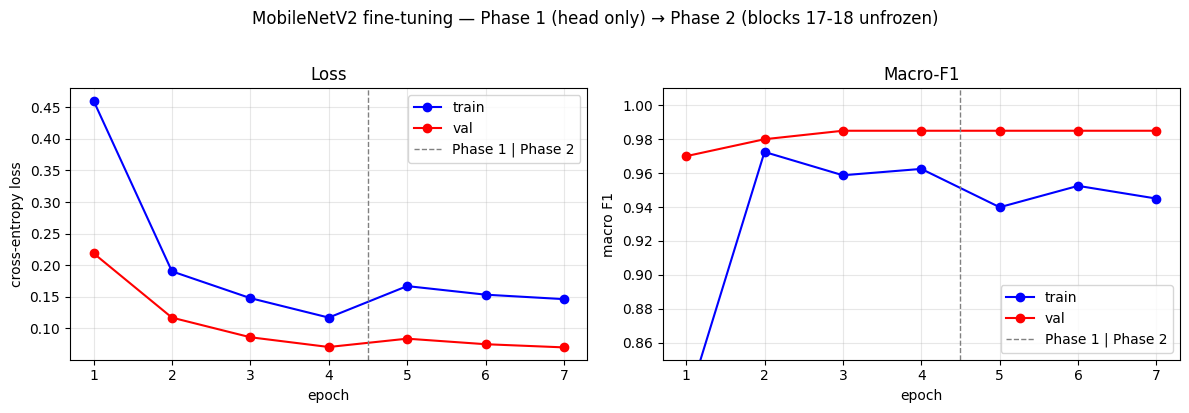

In [15]:
epochs = range(1, len(history["train_f1"]) + 1)
phase_boundary = HEAD_EPOCHS + 0.5   # vertical line between epoch 4 and 5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- Loss ---
ax1.plot(epochs, history["train_loss"], "b-o", label="train")
ax1.plot(epochs, history["val_loss"],   "r-o", label="val")
ax1.axvline(phase_boundary, color="gray", linestyle="--", linewidth=1, label="Phase 1 | Phase 2")
ax1.set_title("Loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- F1 ---
ax2.plot(epochs, history["train_f1"], "b-o", label="train")
ax2.plot(epochs, history["val_f1"],   "r-o", label="val")
ax2.axvline(phase_boundary, color="gray", linestyle="--", linewidth=1, label="Phase 1 | Phase 2")
ax2.set_title("Macro-F1")
ax2.set_xlabel("epoch")
ax2.set_ylabel("macro F1")
ax2.set_ylim(0.85, 1.01)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("MobileNetV2 fine-tuning — Phase 1 (head only) → Phase 2 (blocks 17-18 unfrozen)", y=1.02)
plt.tight_layout()
plt.show()
